In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [138]:
url = '/content/weatherAUS.csv'
df = pd.read_csv(url)
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


# 1. Удаление значения NaN из целевой переменной 'RainTomorrow' не влияет на её распределение

In [139]:
target_col = 'RainTomorrow'

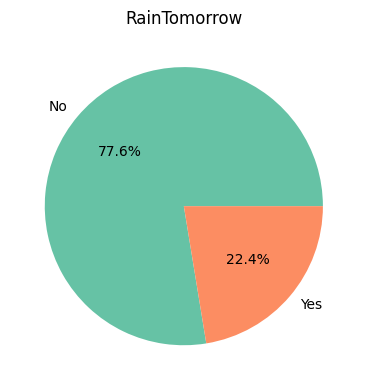

In [140]:
fig, ax = plt.subplots(figsize=(4, 4))
df[target_col].value_counts(normalize=True).plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Set2'))
ax.set_title('RainTomorrow')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [141]:
df.shape

(145460, 23)

In [142]:
df = df.dropna(subset=['RainTomorrow'])

In [143]:
df.shape

(142193, 23)

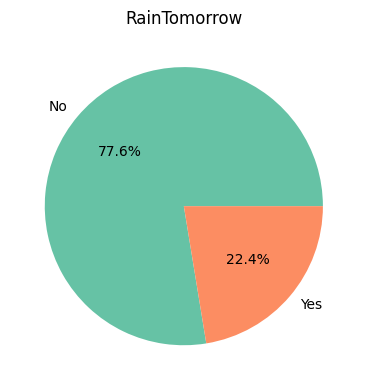

In [144]:
fig, ax = plt.subplots(figsize=(4, 4))
df[target_col].value_counts(normalize=True).plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Set2'))
ax.set_title('RainTomorrow')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Гипотеза 1 подтверждена. Удалены все значения NaN, на соотношение Yes/No это не влияет

In [145]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

In [146]:
df = df.drop(columns=['Date'])

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       142193 non-null  object 
 1   MinTemp        141556 non-null  float64
 2   MaxTemp        141871 non-null  float64
 3   Rainfall       140787 non-null  float64
 4   Evaporation    81350 non-null   float64
 5   Sunshine       74377 non-null   float64
 6   WindGustDir    132863 non-null  object 
 7   WindGustSpeed  132923 non-null  float64
 8   WindDir9am     132180 non-null  object 
 9   WindDir3pm     138415 non-null  object 
 10  WindSpeed9am   140845 non-null  float64
 11  WindSpeed3pm   139563 non-null  float64
 12  Humidity9am    140419 non-null  float64
 13  Humidity3pm    138583 non-null  float64
 14  Pressure9am    128179 non-null  float64
 15  Pressure3pm    128212 non-null  float64
 16  Cloud9am       88536 non-null   float64
 17  Cloud3pm       85099 non-null   fl

In [148]:
df.isna().mean()

,0
Location,0.000000
MinTemp,0.004480
MaxTemp,0.002265
Rainfall,0.009888
Evaporation,0.427890
Sunshine,0.476929
WindGustDir,0.065615
WindGustSpeed,0.065193
WindDir9am,0.070418
WindDir3pm,0.026570


In [149]:
df = df.drop(columns=['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'])

In [150]:
categorical_columns = ['Location', 'WindGustDir', 'WindDir9am',
                      'WindDir3pm', 'RainToday', 'Month']

num_columns = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
               'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
               'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']

# 2. Заполнение NaN средним арифметическим соседей для числовых принаков не меняет распределения

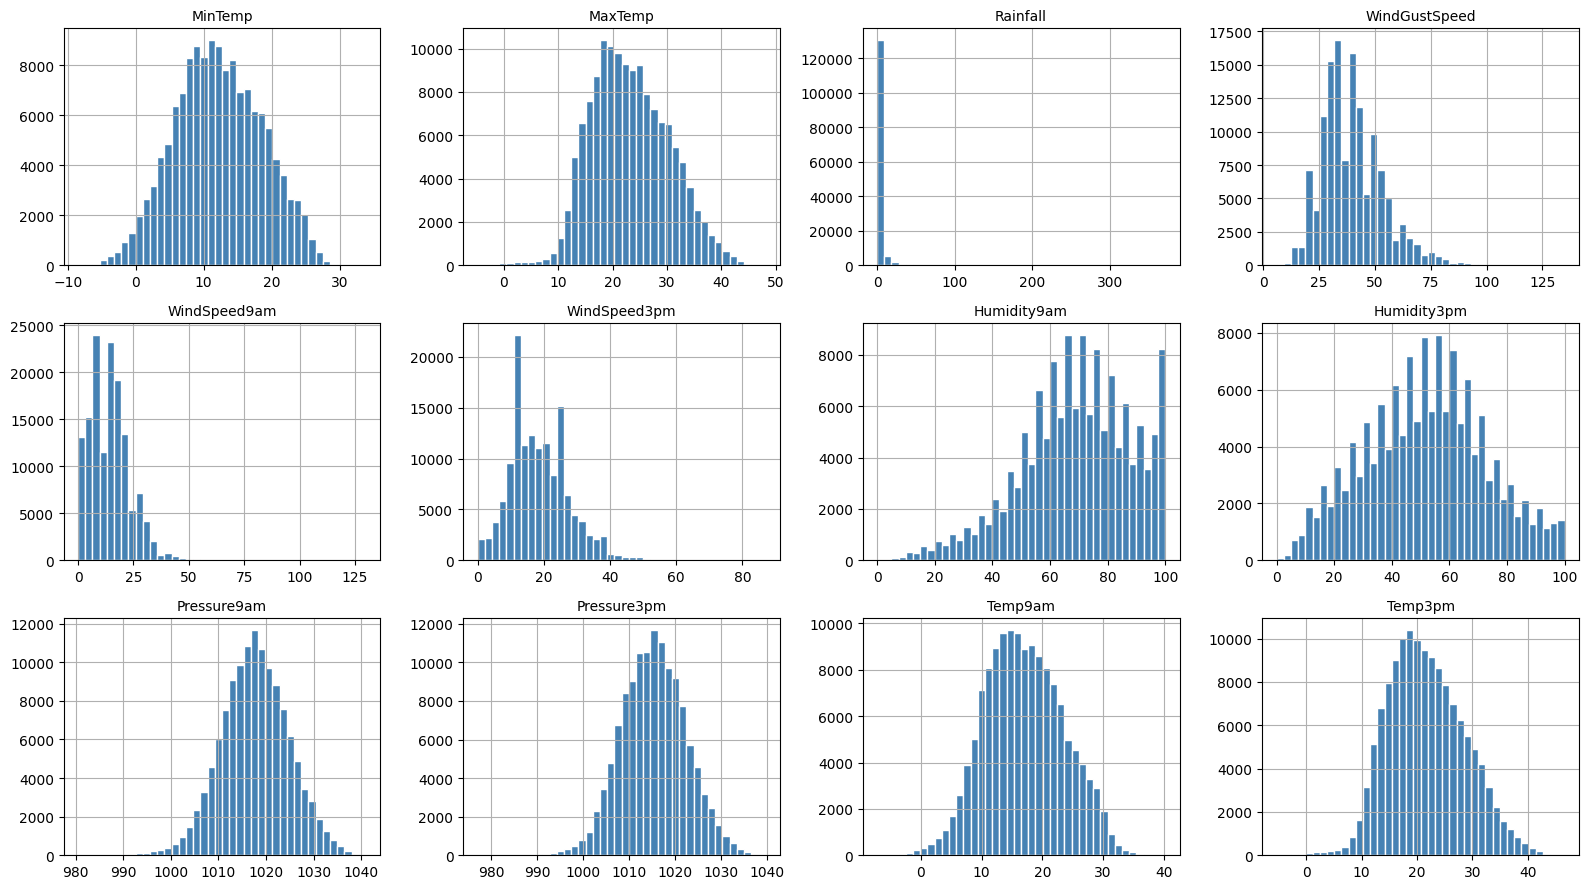

In [151]:
numeric_cols = num_columns

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [152]:
df.isnull().sum()

,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013
WindDir3pm,3778
WindSpeed9am,1348
WindSpeed3pm,2630


In [153]:
for i in num_columns:
  df[i] = df[i].ffill().add(df[i].bfill()).div(2)

In [154]:
df.isnull().sum()

,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
WindGustDir,9330
WindGustSpeed,0
WindDir9am,10013
WindDir3pm,3778
WindSpeed9am,0
WindSpeed3pm,0


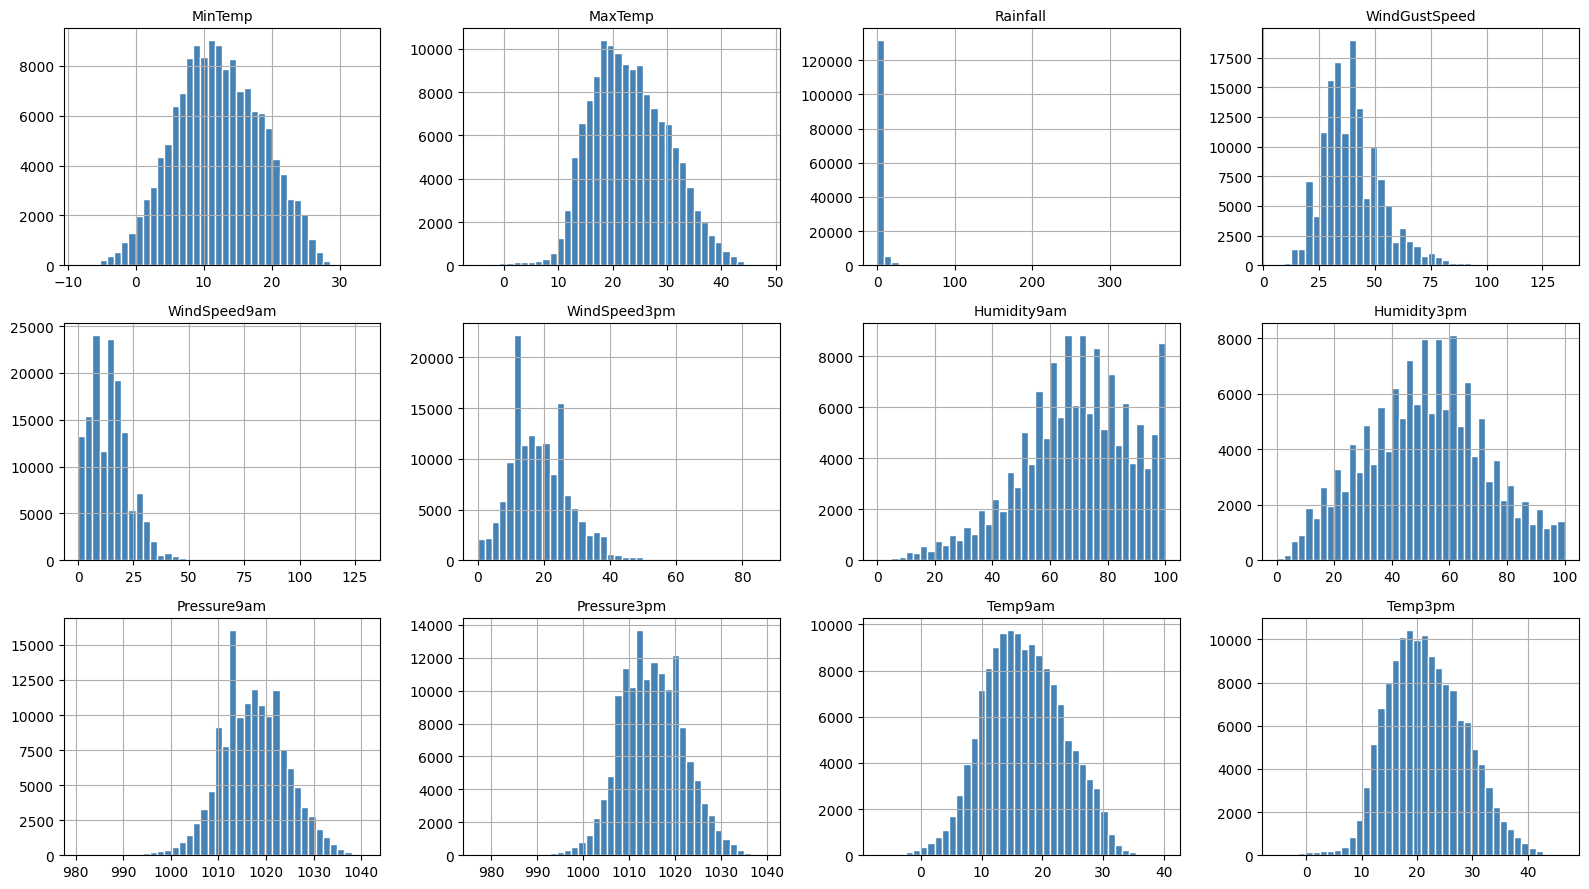

In [155]:
numeric_cols = num_columns

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Гипотеза 2 подтверждена. Заполнение NaN средним арифметическим не портит струтктуры данных, сохраняя их распределение

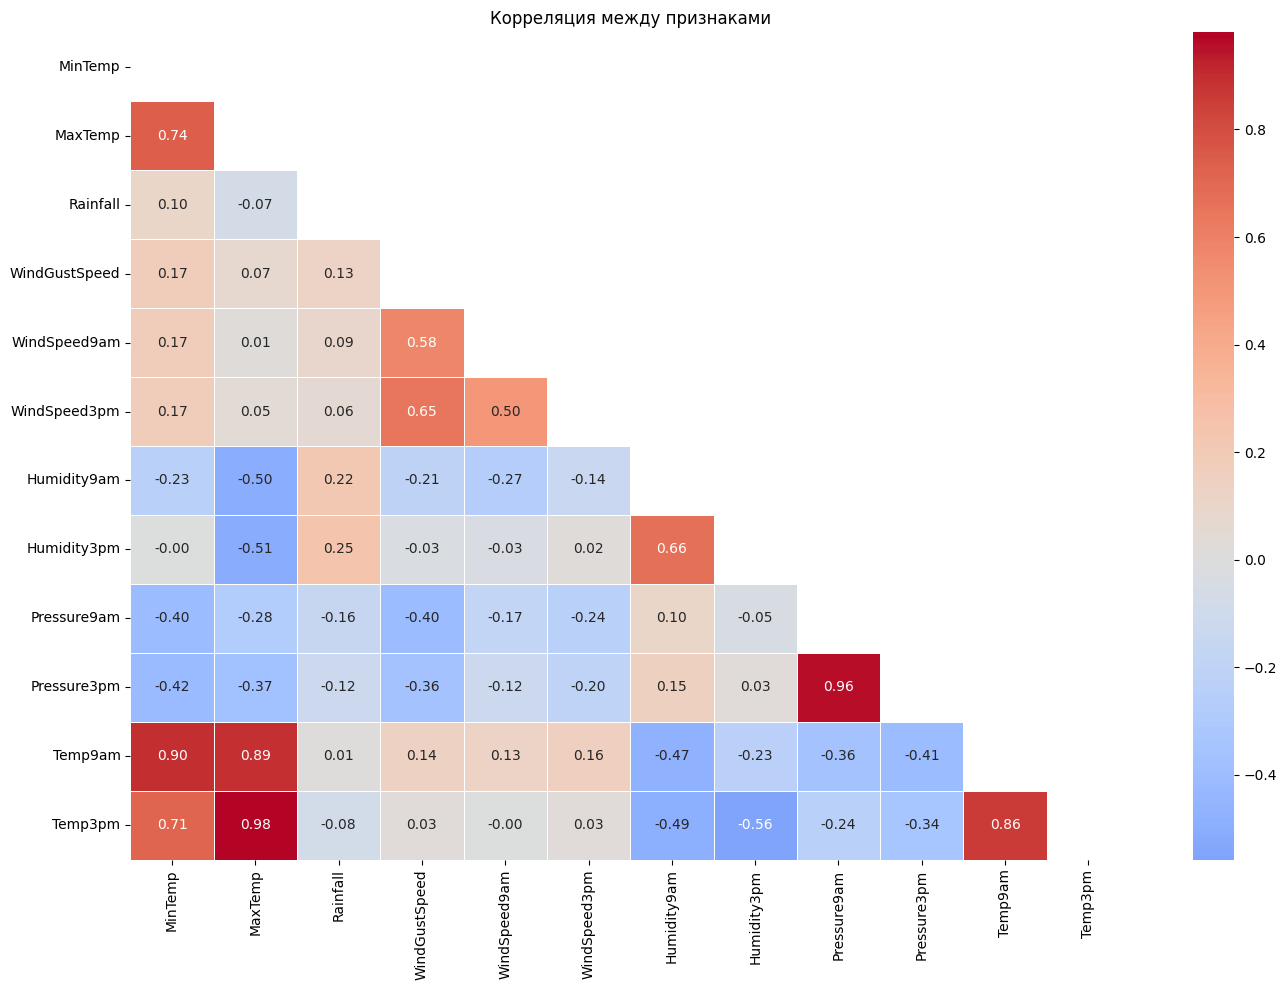

In [156]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

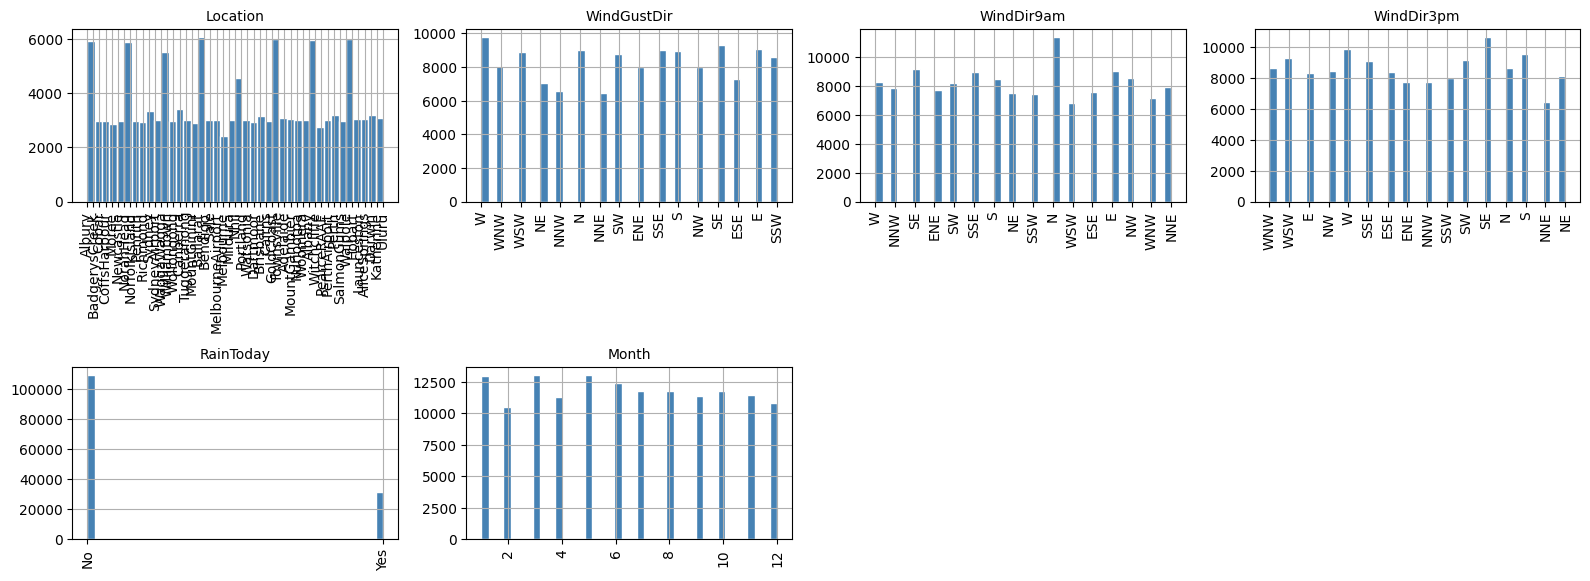

In [157]:
n_cols = len(categorical_columns)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)

for j in range(len(categorical_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 3. Модель DecisionTree лучше LogisticRegression

In [159]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [160]:
X_all = df.drop(columns='RainTomorrow').copy()

In [161]:
X_cls = X_all
y_cls = LabelEncoder().fit_transform(df[target_col])
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

In [163]:
numeric_pipe = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [164]:
num_cols = [i for i in num_columns if i in X_train_cls.columns]
cat_cols = [i for i in categorical_columns if i in X_train_cls.columns]

In [166]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

In [167]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('LogisticRegression', LogisticRegression())])

In [168]:
log_reg = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

In [169]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [170]:
log_reg.fit(X_train_cls, y_train_cls)
y_pred_log_reg = log_reg.predict(X_test_cls)

In [171]:
print('Accuracy :', accuracy_score(y_test_cls, y_pred_log_reg))
print('Precision :', precision_score(y_test_cls, y_pred_log_reg, zero_division=0))
print('Recall :', recall_score(y_test_cls, y_pred_log_reg, zero_division=0))
print('F1 :', f1_score(y_test_cls, y_pred_log_reg, zero_division=0))

Accuracy : 0.8459509828053026
Precision : 0.7305735430157262
Recall : 0.4955294117647059
F1 : 0.5905224787363305


In [174]:
from sklearn.tree import DecisionTreeClassifier

In [175]:
dec_tree = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=10, random_state=42, criterion='gini'))
])

In [176]:
dec_tree.fit(X_train_cls, y_train_cls)
y_pred_dec_tree = dec_tree.predict(X_test_cls)

In [177]:
print('Accuracy :', accuracy_score(y_test_cls, y_pred_dec_tree))
print('Precision :', precision_score(y_test_cls, y_pred_dec_tree, zero_division=0))
print('Recall :', recall_score(y_test_cls, y_pred_dec_tree, zero_division=0))
print('F1 :', f1_score(y_test_cls, y_pred_dec_tree, zero_division=0))

Accuracy : 0.8409578395864834
Precision : 0.6991397849462365
Recall : 0.5099607843137255
F1 : 0.5897505668934241


Гипотеза 3 не верна, нелинейность дерева не даёт улучшения

# 4. Добавление кросс-валидации даст улучшение для DecisionTree по сравнению с LogisticRegression

In [182]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score_log_reg = cross_val_score(log_reg, X_train_cls, y_train_cls, cv=cv, scoring='f1')

In [183]:
print("F1: ", score_log_reg.mean())

F1:  0.5898682725727267


In [184]:
score_dec_tree = cross_val_score(dec_tree, X_train_cls, y_train_cls, cv=cv, scoring='f1')

In [185]:
print("F1: ", score_dec_tree.mean())

F1:  0.5650227732507112


Гипотеза 4 не подтвердилась, из-за несбалансированности данных кросс-валидация не даёт улучшения

# 5. С помощью GreadSearch можно улучшить модели

In [186]:
from sklearn.model_selection import GridSearchCV

In [188]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__class_weight': [None, 'balanced'],
}

grid_search = GridSearchCV(log_reg, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=2)

In [189]:
grid_search.fit(X_train_cls, y_train_cls)
print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
{'model__C': 0.1, 'model__class_weight': 'balanced'}
0.6176137738083316


In [190]:
param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 5, 10],
}

grid_search = GridSearchCV(dec_tree, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=2)

In [192]:
grid_search.fit(X_train_cls, y_train_cls)
print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
0.567474643685018


Гипотеза 5 частично подтвердилась. Улучшение происходит только для LogisticRegression

In [193]:
model = dec_tree.named_steps['model']
names = dec_tree.named_steps['prep'].get_feature_names_out()

fi = (pd.Series(model.feature_importances_, index=names).sort_values(ascending=False))

print(fi.head(10))

num__Humidity3pm      0.574707
num__Rainfall         0.100469
num__WindGustSpeed    0.086375
num__Pressure3pm      0.066935
num__Temp9am          0.021172
num__Temp3pm          0.018259
num__Humidity9am      0.018254
num__MinTemp          0.012520
num__WindSpeed3pm     0.011383
num__Pressure9am      0.011162
dtype: float64


In [195]:
from sklearn.feature_selection import SelectKBest, f_classif

In [199]:
dec_tree_kbest = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=f_classif, k=20)),
    ('model', DecisionTreeClassifier(max_depth=10, random_state=42, criterion='gini')),
])

dec_tree_kbest.fit(X_train_cls, y_train_cls)
y_pred_kbest = dec_tree_kbest.predict(X_test_cls)

print('F1 с отбором 20 признаков:', f1_score(y_test_cls, y_pred_kbest, zero_division=0))

F1 с отбором 20 признаков: 0.5829497330141779
